# Extracción de características

Una vez preprocesadas las señales de audio, el siguiente paso consiste en transformarlas
en una representación numérica que capture la información acústica relevante y que pueda
ser procesada por los algoritmos de clasificación. La elección de esta representación es una
de las decisiones más importantes del proyecto, ya que determina en gran medida qué
información estará disponible para el clasificador y, por tanto, qué rendimiento es posible
alcanzar.

En este proyecto se optó por los Coeficientes Cepstrales en las Frecuencias de
Mel (MFCC), que constituyen el estándar más ampliamente utilizado en tareas de
reconocimiento de fonemas y voz.

## Librerías y funciones

In [49]:
import pandas as pd
import numpy as np
import librosa
from feature_extraction import unificar_mfccs
from tensorflow.keras.utils import to_categorical
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
import seaborn as sns
from scipy.spatial.distance import pdist, squareform

VOCAL_A_COLOR = {
    "a": "#1f2933",  # charcoal
    "e": "#3b82f6",  # soft blue
    "i": "#10b981",  # muted teal
    "o": "#f59e0b",  # warm amber
    "u": "#8b5cf6",  # restrained violet
}



In [50]:
path_data = '../data/'
dataset = 'dataset_limpio_EDA_118.parquet'

In [51]:
df = pd.read_parquet(path_data+dataset)

## Selección y justificación de parámetros

| Parámetro    | Valor     | Justificación técnica |
|-------------|----------|----------------------|
| `sr`        | 22050 Hz | Cubre ampliamente el rango relevante de la voz humana. |
| `n_fft`     | 1024     | Buena resolución frecuencial para vocales sostenidas. |
| `win_length`| 1024     | Coherente con la ventana de análisis. |
| `hop_length`| 256      | 75 % de solapamiento, buena resolución temporal. |
| `n_mfcc`    | 13       | Estándar en reconocimiento del habla. |

In [52]:
LIBROSA_ARGS_DEFAULT = {
    "sr": 22050,
    "n_mfcc": 13,
    "n_fft": 1024,
    "hop_length": 256,
    "win_length": 1024
}


In [53]:
mfccs = df["y"].apply(lambda x: librosa.feature.mfcc(y=x, **LIBROSA_ARGS_DEFAULT))

Hemos generado los **coeficientes MFCC** a partir de señales de audio.Para cada señal de entrada, el resultado es una matriz 2D con la forma:$$(n\_mfcc, T)$$

Donde:

- **n_mfcc = 13**  
  Número de coeficientes MFCC.  
  Cada fila representa un coeficiente espectral diferente.

- **T**  
  Número de frames temporales.  
  Depende de la duración del audio y del `hop_length`.

Cada **columna** de la matriz corresponde a un instante de tiempo (una ventana de análisis),  
y cada **fila** describe la información espectral de la señal en ese instante.

En resumen, el output representa **cómo evoluciona el contenido espectral del audio a lo largo del tiempo**, usando 13 coeficientes MFCC por frame.


## Unificación de longitudes y construcción del vector de características

El resultado de aplicar la extracción de MFCC a cada audio es una matriz de dimensiones 
(13, T), donde T es el número de frames temporales y depende de la duración de cada audio 
y del valor de `hop_length`. Como los audios tienen duraciones variables, las matrices resultantes 
tienen distinto número de columnas, lo que impide alimentarlas directamente a los clasificadores, 
que esperan entradas de dimensión fija.

Para solucionar este problema, se calculó la longitud mediana del conjunto de matrices, que resultó 
ser de 33 frames, equivalente a aproximadamente 1.53 segundos de audio. Los audios más cortos 
que esta longitud se rellenaron mediante *padding* de tipo `edge`, lo cual significa que se añadirá 
silencio en los audios hasta llegar a los 33 frames.

Una vez unificadas las dimensiones, cada matriz (13, 33) fue aplanada a lo largo de los 13 coeficientes, 
resultando en un vector de 429 características por muestra, que constituye la entrada definitiva a los clasificadores.

In [54]:
mfccs_unificados, longitud_frames = unificar_mfccs(mfccs)

Longitud objetivo calculada: 33 frames


Encodificamos nuestras etiquetas y aplanamos los MFCCs para redes densas

In [55]:
label_encoder_vocal = LabelEncoder()

y_vocal = label_encoder_vocal.fit_transform(df['vocal'])

print(f"Clases de vocales: {label_encoder_vocal.classes_}")
X_aplanado = mfccs_unificados.reshape(mfccs_unificados.shape[0], -1)
print(f"\nShape datos aplanados: {X_aplanado.shape}")

Clases de vocales: ['a' 'e' 'i' 'o' 'u']

Shape datos aplanados: (118, 429)


Creamos los conjuntos de entrenamiento

In [56]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X_aplanado,
    y_vocal,
    test_size=0.3,
    random_state=42,
    stratify=y_vocal
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.5,
    random_state=42,
    stratify=y_temp
)

Normalizamos nuestras variables, es importante construir el scaler con los datos de train, y al haber cogido la referencia de la distribución de train, aplicar el escalado al conjunto de validación y prueba. Así evitaremos la fuga de datos y "chivarnos" al set de entrenamiento de la distribución de los conjuntos de validación y prueba.

In [57]:
scaler = StandardScaler()
X_train_norm = scaler.fit_transform(X_train)
X_val_norm = scaler.transform(X_val)
X_test_norm = scaler.transform(X_test)

In [58]:
"Características por muestra: " + str(X_train_norm.shape[1])

'Características por muestra: 429'

Convierto las etiquetas a one-hot encoding

In [59]:
num_clases = len(np.unique(y_train))
y_train_cat = to_categorical(y_train, num_clases)
y_val_cat = to_categorical(y_val, num_clases)
y_test_cat = to_categorical(y_test, num_clases)

print(f"Número de clases: {num_clases}")
print(f"Forma de entrada: {X_train_norm.shape[1]} características")

Número de clases: 5
Forma de entrada: 429 características


Los datos están listos para la fase de entrenamiento y para la fase de reconocimiento de patrones

## Análisis de separabilidad mediante reducción de dimensionalidad

In [60]:
vocales = label_encoder_vocal.classes_
y_test_labels = np.argmax(y_test_cat, axis=1)

In [61]:
X_completo_norm = np.vstack([X_train_norm, X_val_norm, X_test_norm])
y_completo_labels = np.concatenate([y_train, np.argmax(y_val_cat, axis=1), y_test_labels])

print(f"Datos totales: {X_completo_norm.shape[0]} muestras")
print(f"Dimensiones originales: {X_completo_norm.shape[1]} características (MFCCs aplanados)")
print(f"Clases: {len(vocales)} vocales -> {vocales}")

Datos totales: 118 muestras
Dimensiones originales: 429 características (MFCCs aplanados)
Clases: 5 vocales -> ['a' 'e' 'i' 'o' 'u']


### PCA


PCA - Reducción de Dimensionalidad
Varianza explicada por componente:
  PC1: 19.37%
  PC2: 13.66%
  PC3: 10.39%
  PC4: 8.30%
  PC5: 6.98%

Varianza acumulada primeras 2 componentes: 33.04%
Varianza acumulada primeras 3 componentes: 43.43%


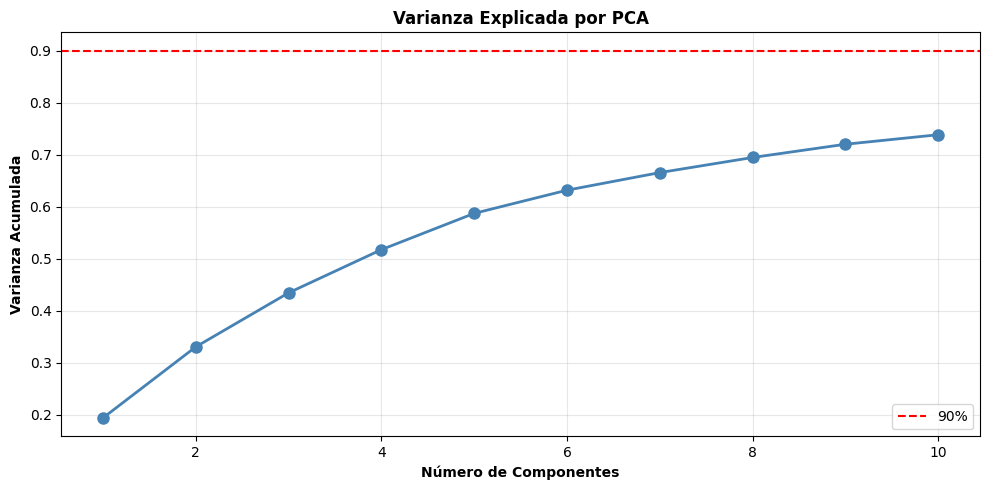

In [62]:

from sklearn.decomposition import PCA

pca = PCA(n_components=10)  # Primeros 10 componentes
X_pca = pca.fit_transform(X_completo_norm)

print("\n" + "="*60)
print("PCA - Reducción de Dimensionalidad")
print("="*60)
print(f"Varianza explicada por componente:")
for i, var in enumerate(pca.explained_variance_ratio_[:5]):
    print(f"  PC{i+1}: {var*100:.2f}%")

print(f"\nVarianza acumulada primeras 2 componentes: {sum(pca.explained_variance_ratio_[:2])*100:.2f}%")
print(f"Varianza acumulada primeras 3 componentes: {sum(pca.explained_variance_ratio_[:3])*100:.2f}%")

# Gráfica de varianza explicada
plt.figure(figsize=(10, 5))
plt.plot(range(1, 11), np.cumsum(pca.explained_variance_ratio_[:10]),
         marker='o', linewidth=2, markersize=8, color='steelblue')
plt.xlabel('Número de Componentes', fontweight='bold')
plt.ylabel('Varianza Acumulada', fontweight='bold')
plt.title('Varianza Explicada por PCA', fontweight='bold')
plt.grid(True, alpha=0.3)
plt.axhline(y=0.90, color='red', linestyle='--', label='90%')
plt.legend()
plt.tight_layout()
plt.show()

### LDA

In [63]:
lda = LinearDiscriminantAnalysis(n_components=4)  # Máximo 4 componentes (5 clases - 1)
X_lda = lda.fit_transform(X_completo_norm, y_completo_labels)

print("\n" + "="*60)
print("LDA - Maximiza Separación entre Vocales")
print("="*60)
print(f"Componentes LDA creados: {X_lda.shape[1]}")
print(f"Varianza explicada por componente:")
for i, var in enumerate(lda.explained_variance_ratio_):
    print(f"  LD{i+1}: {var*100:.2f}%")


LDA - Maximiza Separación entre Vocales
Componentes LDA creados: 4
Varianza explicada por componente:
  LD1: 57.62%
  LD2: 27.12%
  LD3: 10.82%
  LD4: 4.44%


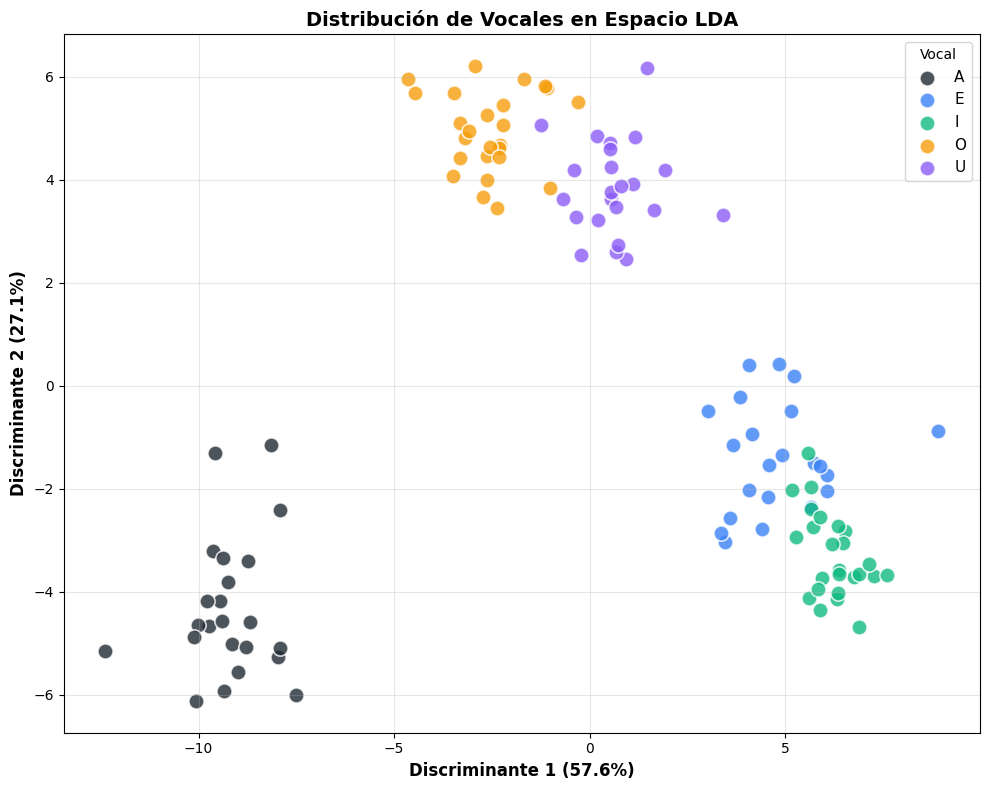

In [64]:
plt.figure(figsize=(10, 8))

for i, vocal in enumerate(vocales):
    indices = y_completo_labels == i
    plt.scatter(
      X_lda[indices, 0],
      X_lda[indices, 1],
      c=VOCAL_A_COLOR[vocal],
      marker="o",
      s=120,
      alpha=0.8,
      edgecolors="white",
      linewidths=1.2,
      label=vocal.upper(),
    )

plt.xlabel(f'Discriminante 1 ({lda.explained_variance_ratio_[0]*100:.1f}%)',
           fontweight='bold', fontsize=12)
plt.ylabel(f'Discriminante 2 ({lda.explained_variance_ratio_[1]*100:.1f}%)',
           fontweight='bold', fontsize=12)
plt.title('Distribución de Vocales en Espacio LDA', fontweight='bold', fontsize=14)
plt.legend(title='Vocal', fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Comparación

¿Las direcciones de máxima varianza coinciden con las de máxima discriminación?

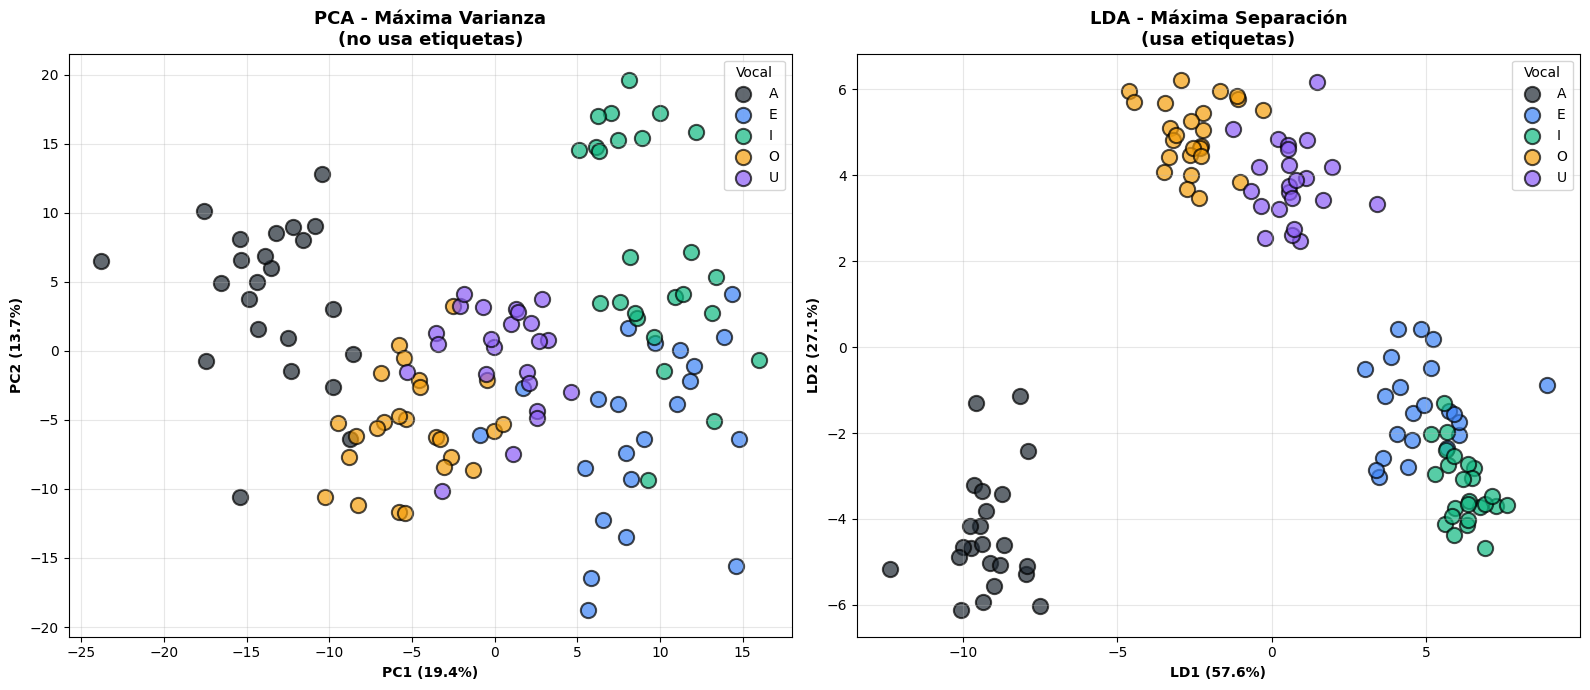

In [ ]:

fig, axes = plt.subplots(1, 2, figsize=(16, 7))


for i, vocal in enumerate(vocales):
    indices = y_completo_labels == i
    axes[0].scatter(X_pca[indices, 0], X_pca[indices, 1],
                    c=VOCAL_A_COLOR[vocal],
                    marker="o",
                    s=120,
                    alpha=0.7,
                    edgecolors='black',
                    linewidths=1.5,
                    label=vocal.upper())

axes[0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)', fontweight='bold')
axes[0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)', fontweight='bold')
axes[0].set_title('PCA - Máxima Varianza\n(no usa etiquetas)', fontweight='bold', fontsize=13)
axes[0].legend(title='Vocal')
axes[0].grid(True, alpha=0.3)

for i, vocal in enumerate(vocales):
    indices = y_completo_labels == i
    axes[1].scatter(X_lda[indices, 0], X_lda[indices, 1],
                    c=VOCAL_A_COLOR[vocal],
                    marker="o",
                    s=120,
                    alpha=0.7,
                    edgecolors='black',
                    linewidths=1.5,
                    label=vocal.upper())

axes[1].set_xlabel(f'LD1 ({lda.explained_variance_ratio_[0]*100:.1f}%)', fontweight='bold')
axes[1].set_ylabel(f'LD2 ({lda.explained_variance_ratio_[1]*100:.1f}%)', fontweight='bold')
axes[1].set_title('LDA - Máxima Separación\n(usa etiquetas)', fontweight='bold', fontsize=13)
axes[1].legend(title='Vocal')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

LDA separa mejor las vocales porque está entrenado específicamente para ello

### Análisis de separabilidad

In [66]:
centroides_lda = []
for i in range(len(vocales)):
    centroide = np.mean(X_lda[y_completo_labels == i], axis=0)
    centroides_lda.append(centroide)

centroides_lda = np.array(centroides_lda)

print("\n" + "="*60)
print("Separabilidad entre Vocales (en espacio LDA)")
print("="*60)


Separabilidad entre Vocales (en espacio LDA)


In [67]:
distancias = squareform(pdist(centroides_lda[:, :2]))  # Solo primeras 2 dimensiones
distancias_df = pd.DataFrame(distancias, index=vocales, columns=vocales)

print("\nDistancias entre vocales:")
print(distancias_df.round(2))



Distancias entre vocales:
       a      e      i      o      u
a   0.00  14.31  15.49  11.41  12.81
e  14.31   0.00   2.38   9.71   6.69
i  15.49   2.38   0.00  12.04   9.07
o  11.41   9.71  12.04   0.00   3.38
u  12.81   6.69   9.07   3.38   0.00


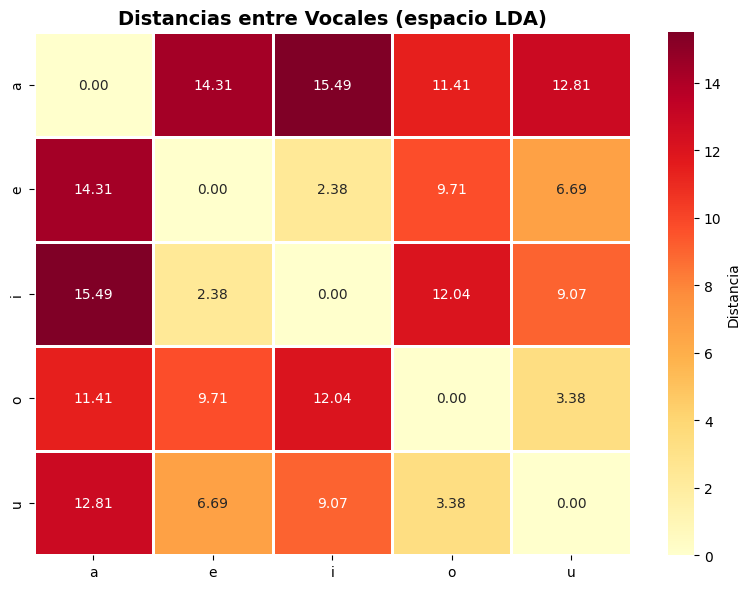

In [68]:
plt.figure(figsize=(8, 6))
sns.heatmap(distancias_df, annot=True, fmt='.2f', cmap='YlOrRd',
            cbar_kws={'label': 'Distancia'}, linewidths=1)
plt.title('Distancias entre Vocales (espacio LDA)', fontweight='bold', fontsize=14)
plt.tight_layout()
plt.show()

In [69]:
distancias_planas = []
for i in range(len(vocales)):
    for j in range(i+1, len(vocales)):
        distancias_planas.append({
            'Par': f'{vocales[i].upper()}-{vocales[j].upper()}',
            'Distancia': distancias[i, j]
        })

distancias_planas = pd.DataFrame(distancias_planas).sort_values('Distancia', ascending=False)

print(f"Vocales MÁS separables: {distancias_planas.iloc[0]['Par']} (dist={distancias_planas.iloc[0]['Distancia']:.2f})")
print(f"Vocales MENOS separables: {distancias_planas.iloc[-1]['Par']} (dist={distancias_planas.iloc[-1]['Distancia']:.2f})")

Vocales MÁS separables: A-I (dist=15.49)
Vocales MENOS separables: E-I (dist=2.38)


## Conclusión

El análisis exploratorio mostró que las 429 dimensiones generadas por los MFCC contienen información discriminativa suficiente para clasificar las cinco vocales. Aunque el PCA indicó que la varianza está distribuida a lo largo de muchas dimensiones y no permite separar claramente las clases en dos componentes, el LDA demostró que las vocales se agrupan en regiones diferenciadas en un espacio bidimensional.  

Se identificaron pares de vocales con distinta facilidad de clasificación: **A–I** es fácilmente separable, mientras que **E–I** presenta mayor riesgo de confusión. Estos resultados anticipan el desempeño esperado de los clasificadores y confirman la relevancia de las características MFCC para el problema.